In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [2]:
with open(r"C:\DSV_APP\Analytics_DEV\JIRA_Export\kanban_jira_completo.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

df['Criado_Tarefa_Pai'] = pd.to_datetime(df['Criado_Tarefa_Pai'], unit='ms')
df['Atualizado_Tarefa_Pai'] = pd.to_datetime(df['Atualizado_Tarefa_Pai'], unit='ms')

df = df[df['Criado_Tarefa_Pai'].dt.year == 2025]
df.fillna({'SubTarefa_Key': 'Sem Subtarefa', 
           'Resumo_SubTarefa': 'Sem Subtarefa', 
           'Status_SubTarefa': 'Sem Subtarefa'}, inplace=True)

df.head()

,Tarefa_Pai,Resumo_Tarefa_Pai,Chave_Tarefa_Pai,Criado_Tarefa_Pai,Atualizado_Tarefa_Pai,Status_Tarefa_Pai,SubTarefa_Key,Resumo_SubTarefa,Status_SubTarefa,Criado_SubTarefa,Atualizado_SubTarefa,Dias_para_Atualizar_Pai,Dias_para_Atualizar_Sub
0,MTE-2840,[OUTAGE] Melhorias nas regras de abertura de o...,MTE-2840,2025-04-07 17:37:00.290,2025-08-08 13:26:42.932,Refinamento Técnico/Especifica,Sem Subtarefa,Sem Subtarefa,Sem Subtarefa,None,None,122,None
1,MTE-2578,[HABILITADOR] TV BOX - Melhoria na Coleta do S...,MTE-2578,2025-02-12 17:00:46.129,2025-08-08 12:40:15.367,Em Homologação,MTE-3271,Criação da massa de Testes,Concluído,None,None,176,None
2,MTE-2578,[HABILITADOR] TV BOX - Melhoria na Coleta do S...,MTE-2578,2025-02-12 17:00:46.129,2025-08-08 12:40:15.367,Em Homologação,MTE-3280,Ajuste entre as massas de teste de acordo com ...,Concluído,None,None,176,None
3,MTE-2578,[HABILITADOR] TV BOX - Melhoria na Coleta do S...,MTE-2578,2025-02-12 17:00:46.129,2025-08-08 12:40:15.367,Em Homologação,MTE-3299,Desenvolvimento,Concluído,None,None,176,None
4,MTE-2578,[HABILITADOR] TV BOX - Melhoria na Coleta do S...,MTE-2578,2025-02-12 17:00:46.129,2025-08-08 12:40:15.367,Em Homologação,MTE-3273,Teste unitário,Concluído,None,None,176,None


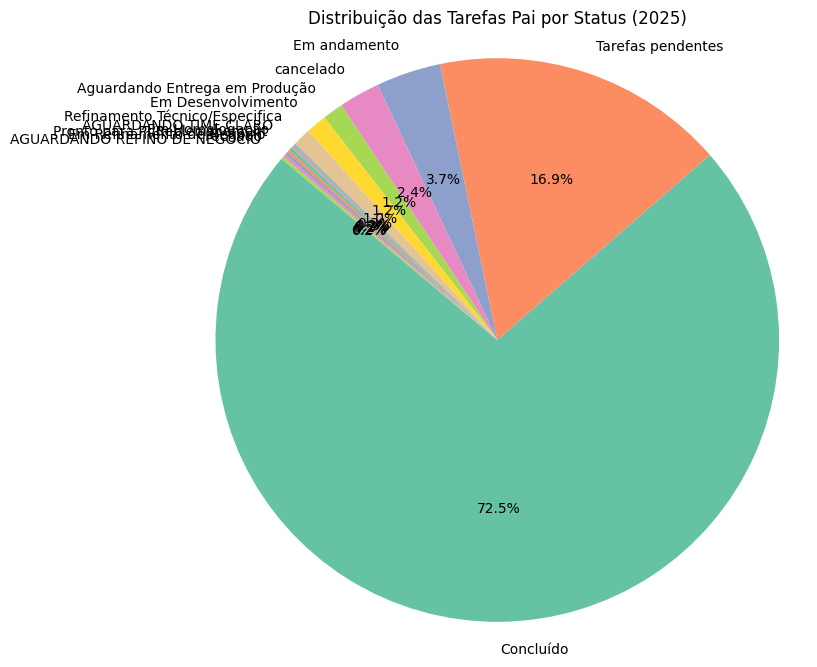

In [3]:
status_pai = df[['Chave_Tarefa_Pai', 'Status_Tarefa_Pai']].drop_duplicates()
status_counts = status_pai['Status_Tarefa_Pai'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2"))
plt.title("Distribuição das Tarefas Pai por Status (2025)")
plt.axis('equal')
plt.show()

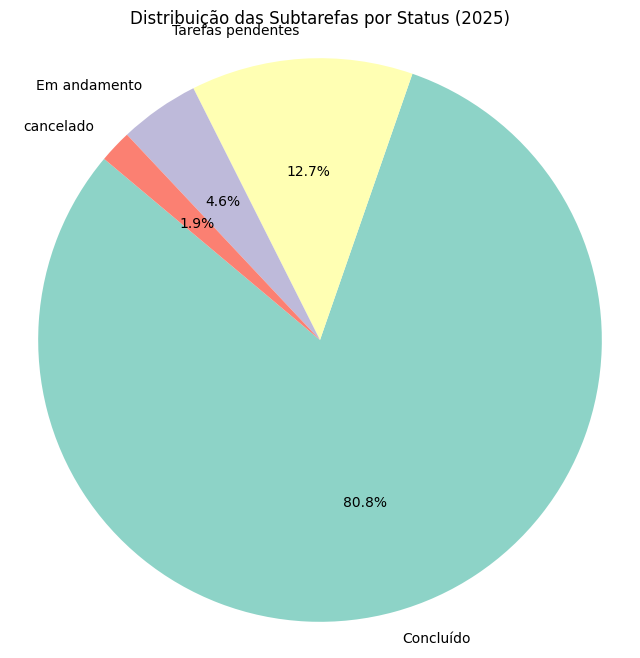

In [4]:
status_sub = df[df['SubTarefa_Key'] != 'Sem Subtarefa']['Status_SubTarefa'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(status_sub.values, labels=status_sub.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3"))
plt.title("Distribuição das Subtarefas por Status (2025)")
plt.axis('equal')
plt.show()

In [5]:
colunas = [
    'Tarefa_Pai', 'Resumo_Tarefa_Pai', 'Status_Tarefa_Pai',
    'SubTarefa_Key', 'Resumo_SubTarefa', 'Status_SubTarefa',
    'Dias_para_Atualizar_Pai'
]

df_tabela = df[colunas].drop_duplicates().sort_values(by='Dias_para_Atualizar_Pai', ascending=False)

import IPython.display as display
display.display(df_tabela.head(15))

,Tarefa_Pai,Resumo_Tarefa_Pai,Status_Tarefa_Pai,SubTarefa_Key,Resumo_SubTarefa,Status_SubTarefa,Dias_para_Atualizar_Pai
107,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,cancelado,MTE-2392,PIT,cancelado,210
108,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,cancelado,MTE-2391,Abrir / Aprovar / Implantar RDM,cancelado,210
105,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,cancelado,MTE-2394,Plano de Teste,Concluído,210
104,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,cancelado,MTE-2395,Teste Unitário,Concluído,210
103,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,cancelado,MTE-2396,Configuração do HPA,Concluído,210
102,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,cancelado,MTE-2436,Documento de Refino,Concluído,210
101,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,cancelado,MTE-2345,Análise do uso de métricas externas para dispa...,Concluído,210
106,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,cancelado,MTE-2393,Homologação,cancelado,210
129,MTE-2345,Análise do uso de métricas externas para dispa...,Concluído,Sem Subtarefa,Sem Subtarefa,Sem Subtarefa,206
26,MTE-2369,[Outage MDU]: Outage por falha de energia elé...,Aguardando Entrega em Produção,MTE-2884,RDM,Tarefas pendentes,206


In [6]:
df_maiores_atrasos = df_tabela[df_tabela['Dias_para_Atualizar_Pai'] > 60]
print("Tarefas com mais de 60 dias sem atualização (2025):")
display.display(df_maiores_atrasos[['Tarefa_Pai', 'Resumo_Tarefa_Pai', 'Dias_para_Atualizar_Pai']])

Tarefas com mais de 60 dias sem atualização (2025):


,Tarefa_Pai,Resumo_Tarefa_Pai,Dias_para_Atualizar_Pai
107,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,210
108,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,210
105,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,210
104,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,210
103,MTE-2284,[MELHORIA] Teste de configuração de autoscale ...,210
...,...,...,...
342,MTE-3027,[Recomendação] Criação do log de recomendação ...,61
401,MTE-2981,Revisão das Descrições das APIs do Motor no po...,61
767,MTE-2749,Acompanhamento pós-implantação,61
402,MTE-2980,Apoio Teste Beegol (Baixa de Velocidade) - Solar,61
